--- Lab 4: MNIST Deep Neural Network ---
Enter number of epochs (default 5): 
Enter batch size (default 32): 

Loading and normalizing MNIST dataset...
Training DNN for 5 epochs...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9288 - loss: 0.2423
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9683 - loss: 0.1031
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9771 - loss: 0.0723
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9819 - loss: 0.0558
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9860 - loss: 0.0437

--- Final Results ---
Test Accuracy: 97.74%

Visualizing training history...


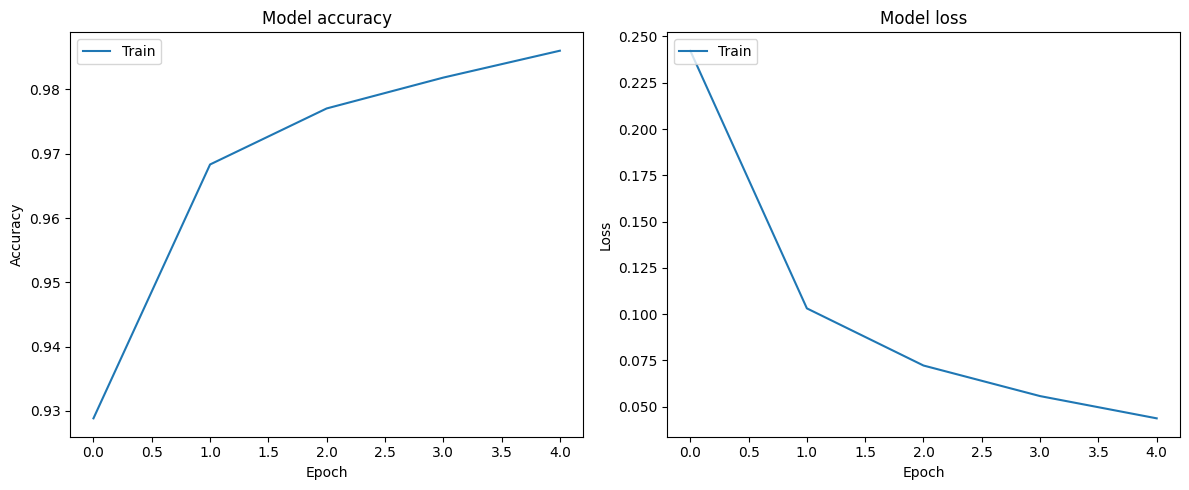

In [6]:



import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

def build_mnist_dnn(hidden1=128, hidden2=64):
    """Builds the MNIST DNN architecture."""
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(hidden1, activation='relu'),
        layers.Dense(hidden2, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

if __name__ == "__main__":
    print("--- Lab 4: MNIST Deep Neural Network ---")

    try:
        # 1. Hyperparameters
        epochs = int(input("Enter number of epochs (default 5): ") or 5)
        batch_size = int(input("Enter batch size (default 32): ") or 32)

        # 2. Load and Preprocess
        print("\nLoading and normalizing MNIST dataset...")
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
        x_train, x_test = x_train / 255.0, x_test / 255.0

        # 3. Build and Train
        model = build_mnist_dnn()
        print(f"Training DNN for {epochs} epochs...")
        # Store the history object from model.fit
        history_callback = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)

        # 4. Evaluate
        print("\n--- Final Results ---")
        loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
        print(f"Test Accuracy: {accuracy*100:.2f}%")

        # 5. Visualize Training History
        print("\nVisualizing training history...")
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(history_callback.history['accuracy'])
        plt.title('Model accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend(['Train'], loc='upper left')

        plt.subplot(1, 2, 2)
        plt.plot(history_callback.history['loss'])
        plt.title('Model loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train'], loc='upper left')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"\nError: {e}")